In [1]:
# Linear Classifier

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('/content/diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
lc = SGDClassifier()

SGD is stochastic gradient descent.

In [10]:
lc.fit(X_train, y_train)

SGDClassifier()

In [11]:
lc.score(X_train, y_train)

0.6547231270358306

In [12]:
lc.score(X_test, y_test)

0.6818181818181818

Score/accuracy is around 60% which is not great.

In [13]:
df1 = pd.DataFrame({"x1": [1, 2, 1, 3, 4, 4], "x2": [1, 3, 4, 1, 2, 4], "y": [0, 0, 0, 1, 1, 1]})

In [15]:
X = df1[["x1", "x2"]]
y = df1["y"]

In [16]:
sgd = SGDClassifier()

In [17]:
sgd.fit(X, y)

SGDClassifier()

In [18]:
sgd.score(X, y)

1.0

In [20]:
sgd.predict([[2, 3]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([0])

In [21]:
sgd.coef_

array([[ 65.35947712, -46.6853408 ]])

In [22]:
sgd.intercept_

array([-49.12184486])

In [23]:
sgd.predict([[3, 1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([1])

In [34]:
import matplotlib.pyplot as plt

In [25]:
from sklearn.svm import SVC


Linear classifier just draws a line which may have the problem that some of the data points are misclassified (it draws a line which may not be the best) where as SVM draws two parallel lines and the distance between two lines is divided in half and the line in middle is chosen as the classification lines.

SVC supports three kernels. Depending on the shape of data you have to choose between poly (polinomial), RBDF (Circle ) and Linear.

1. Apply poly kernel and check for accuracy
2. Apply RBF kernel and check for accuracy
3. Apply Linear kernel and check for accuracy

Which ever gives best accuracy, the data is of that shape.

In [27]:
sv = SVC(kernel='linear') #

In [29]:
sv.fit(X,y)

SVC(kernel='linear')

In [31]:
sv.score(X, y)

1.0

In [32]:
sv.predict([[2, 3]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])

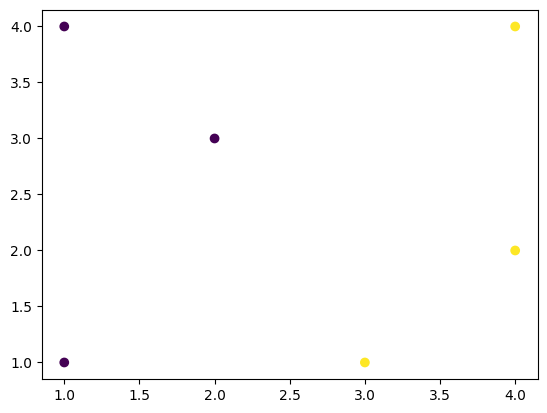

In [35]:
plt.scatter(df1['x1'], df1['x2'], c=df1['y'])
plt.show()

In [33]:
sv.support_vectors_ # It gives the points which are used as the boudary for hyper planes. which means farthest point(s) from origin for first data set
# nearest point(s) from origin for second dataset. Watch video from 14 October timeline around 56 mins

array([[2., 3.],
       [3., 1.],
       [4., 4.]])

In [36]:
from sklearn.svm import SVC

In [37]:
df2 = pd.read_csv('/content/diabetes.csv')

In [38]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [39]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [40]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
svc = SVC(kernel='linear')

In [43]:
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [45]:
svc.score(X_test, y_test)

0.7532467532467533

In [47]:
svc.score(X_train, y_train)

0.7736156351791531

In [48]:
svc = SVC(kernel='poly')

In [49]:
svc.fit(X_train, y_train)

SVC(kernel='poly')

In [50]:
svc.score(X_test, y_test)

0.7597402597402597

In [51]:
svc = SVC(kernel='rbf')

In [52]:
svc.fit(X_train, y_train)

SVC()

In [53]:
svc.score(X_test, y_test)

0.7662337662337663

So far we have covered


1.   Linear Regression
2.   Logistic Regression
3.   SGD is stochastic gradient descent.
4.   SVC Support Vector Classifier